Крок 0. Імпортуємо бібліотеки які будемо використовувати для даного завдання

In [239]:
%load_ext autoreload
%autoreload 2

from process_marketing_calls import preprocess_data

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import plot_tree, export_text
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from numpy.random import default_rng
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from typing import Tuple, List
import lightgbm as lgb
from sklearn.base import clone

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Крок 1. Завантажуємо дані та виводимо перші 10 стрічок. Також виводио загальну інформацію про датасет.

In [3]:
raw_df = pd.read_csv('bank-additional-full.csv', sep=';')

raw_df.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

Маємо 11 категоріальних колонок та 10 числових.

In [5]:
numeric_cols = raw_df.select_dtypes(include='number').columns.tolist()
categorical_cols = raw_df.select_dtypes(include='object').columns.tolist()

In [6]:
numeric_cols

['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

In [7]:
categorical_cols

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome',
 'y']

In [8]:
raw_df['deposit_subscribed'] = raw_df['y'].map({'yes': 1, 'no': 0})

In [9]:
fig = px.histogram(
    raw_df,
    x='age',
    color='y',
    histnorm='probability density',
    marginal='box',
    barmode='overlay',
    opacity=0.6
)
fig.update_layout(bargap=0.1)
fig.show()

<Axes: title={'center': 'Конверсія за віковими групами'}, xlabel='age_group'>

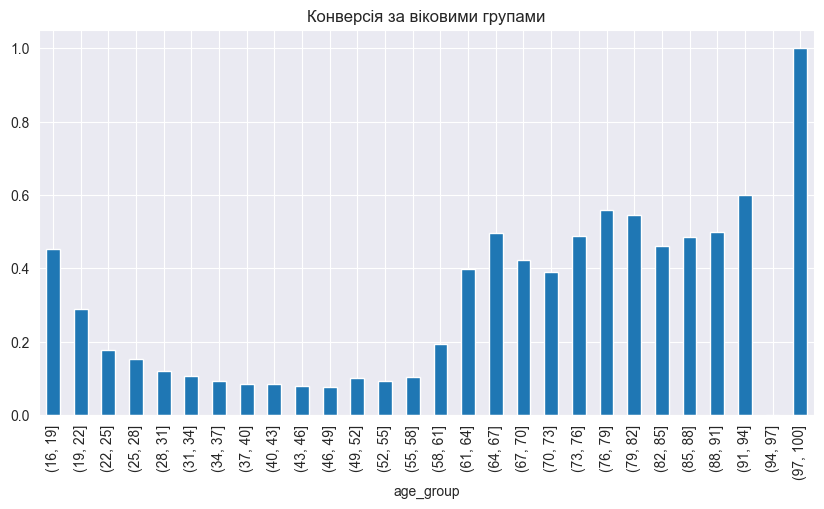

In [70]:
raw_df["age_group"] = pd.cut(
    raw_df["age"],
    bins=range(16, 103, 3)
)
conversion = raw_df.groupby('age_group', observed=True)["deposit_subscribed"].mean()
conversion.plot(kind='bar', figsize=(10, 5), title="Конверсія за віковими групами")

Як видно з графіку, спостерігається залежність цільової змінної від віку респондента. Висока конверсія у респондентів після 60 р і від 18 до 21 р.

In [11]:
job_rate = raw_df.groupby('job')['deposit_subscribed'].mean().sort_values(ascending=False)
print(job_rate)

job
student          0.314286
retired          0.252326
unemployed       0.142012
admin.           0.129726
management       0.112175
unknown          0.112121
technician       0.108260
self-employed    0.104856
housemaid        0.100000
entrepreneur     0.085165
services         0.081381
blue-collar      0.068943
Name: deposit_subscribed, dtype: float64


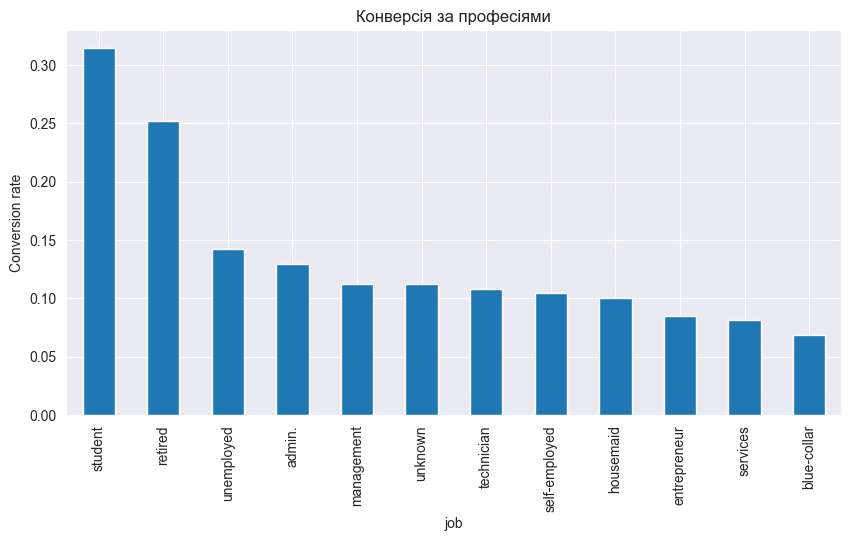

In [21]:
job_rate.plot(kind="bar", figsize=(10, 5))
plt.ylabel("Conversion rate")
plt.title("Конверсія за професіями")
plt.show()

Спостерігаємо кореляцію успішності дзвінків по певних професіях, серед лідерів студенти та пенсіонери, що також корелюється з віком респондентів.

In [13]:
px.violin(
    raw_df,
    y='duration',
    x='y',
    box=True,
    points='all'
)

Закономірно більша тривалість успішних дзвінків, респонденти зацікавлені і менеджери "дотискають" клієнтів. Для навчання моделей використовувати немає сенсу, оскільки це прямий витік даних.

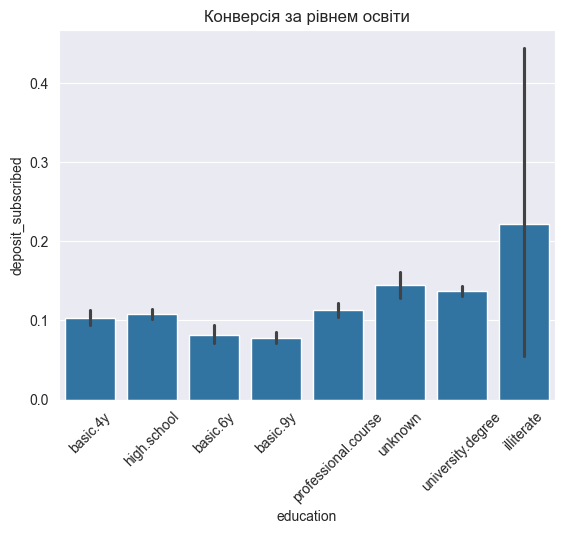

In [22]:
sns.barplot(
    data=raw_df,
    x="education",
    y="deposit_subscribed"
)

plt.xticks(rotation=45)
plt.title("Конверсія за рівнем освіти")
plt.show()

In [15]:
raw_df["education"].value_counts()

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

Бачимо що рівень освіти також має вплив. Найбільше успішних дзвінків спостерігаємо у категорії illiterate, university.degree, unknown. Проте клієнтів з рівнем освіти illiterate занадто мало (18), в порівнянні з іншими категоріями, і це скоріш за все випадковий фактор (шум). Для препроцесингу доцільно буде використати групування за рівнем освіти і також залишити unknown, оскільки ця ознака має вплив.

In [16]:
px.violin(raw_df, y='euribor3m', x='y')

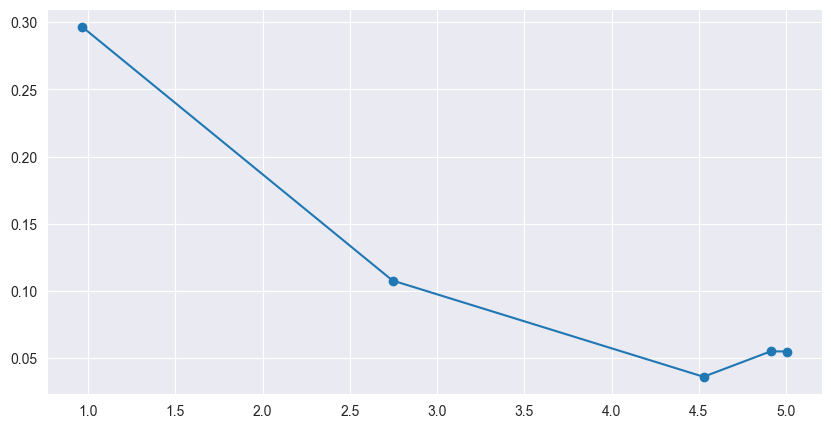

In [53]:
bins = pd.qcut(raw_df["euribor3m"], q=5)

raw_df.groupby(bins, observed=True)["deposit_subscribed"].mean()

conv = raw_df.groupby(bins, observed=True)["deposit_subscribed"].mean()

plt.figure(figsize=(10, 5))
x = [interval.mid for interval in conv.index]
plt.plot(x, conv.values, marker='o')
plt.show()

Можемо спостерігати залежність успішності дзвінків (підписання депозитної угоди) і ставки euribor3m. Гіпотеза - висока ставка свідчить про фінансову кризу та нестабільність (банками важче залучати депозити) - тому клієнти неохоче розміщують депозити.

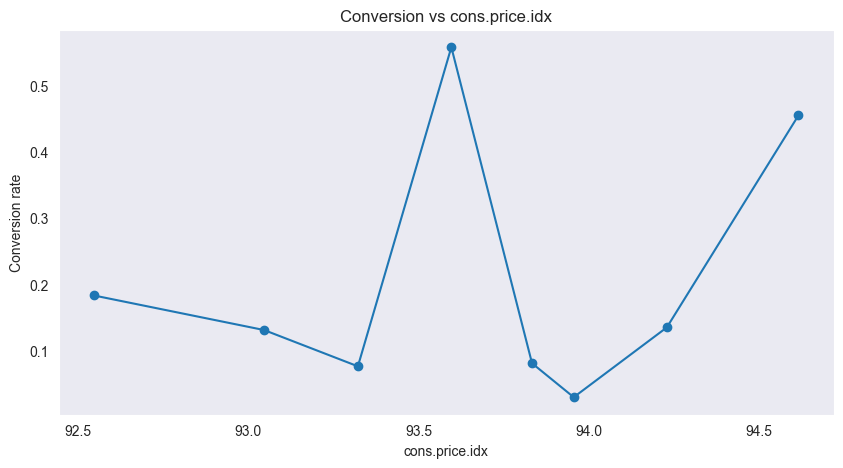

In [56]:
bins = pd.qcut(raw_df["cons.price.idx"], q=10, duplicates='drop')

conv = raw_df.groupby(bins, observed=True)["deposit_subscribed"].mean()
x = [interval.mid for interval in conv.index]

plt.figure(figsize=(10, 5))
plt.plot(x, conv.values, marker='o')
plt.title("Conversion vs cons.price.idx")
plt.xlabel("cons.price.idx")
plt.ylabel("Conversion rate")
plt.grid()
plt.show()

 Гіпотеза - слабка або відсутня кореляція cons.price.idx, нестабільні біни не показують реального тренду.

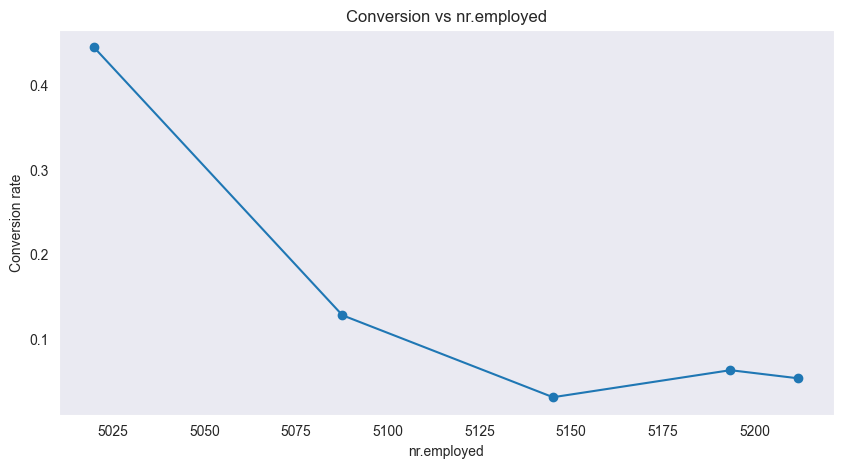

In [61]:
bins = pd.qcut(raw_df["nr.employed"], q=10, duplicates='drop')

conv = raw_df.groupby(bins, observed=True)["deposit_subscribed"].mean()
x = [interval.mid for interval in conv.index]

plt.figure(figsize=(10, 5))
plt.plot(x, conv.values, marker='o')
plt.title("Conversion vs nr.employed")
plt.xlabel("nr.employed")
plt.ylabel("Conversion rate")
plt.grid()
plt.show()

Гіпотеза - кількість працевлаштованих осіб сильно корелює з цільовою змінною.

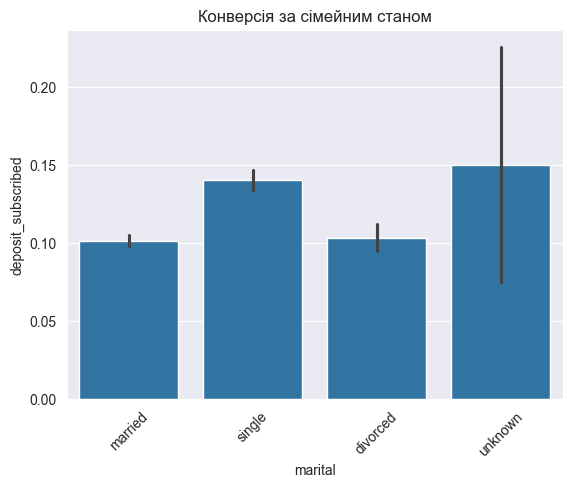

In [29]:
sns.barplot(
    data=raw_df,
    x="marital",
    y="deposit_subscribed"
)

plt.xticks(rotation=45)
plt.title("Конверсія за сімейним станом")
plt.show()

Спостерігається слабка кореляція конверсії з сімейним станом, краща конверсія у самотніх клієнтів. Також є група unknown - тут найбільша конверсія.

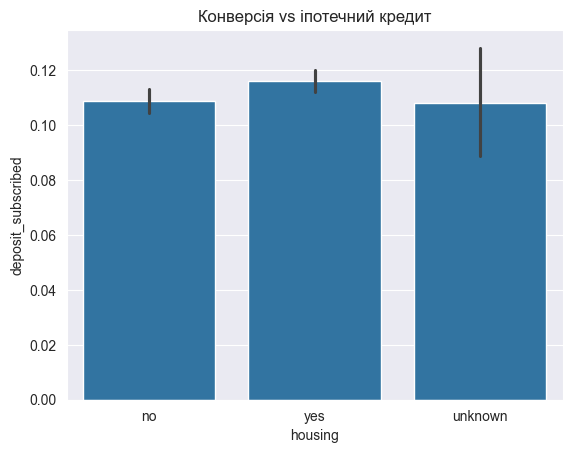

In [31]:
sns.barplot(
    data=raw_df,
    x="housing",
    y="deposit_subscribed"
)

plt.title("Конверсія vs іпотечний кредит")
plt.show()

Слабка кореляція, різниця між групами незначна.

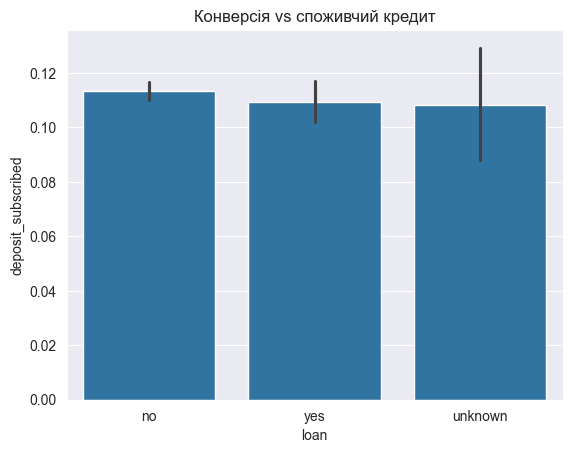

In [34]:
sns.barplot(
    data=raw_df,
    x="loan",
    y="deposit_subscribed"
)

plt.title("Конверсія vs споживчий кредит")
plt.show()

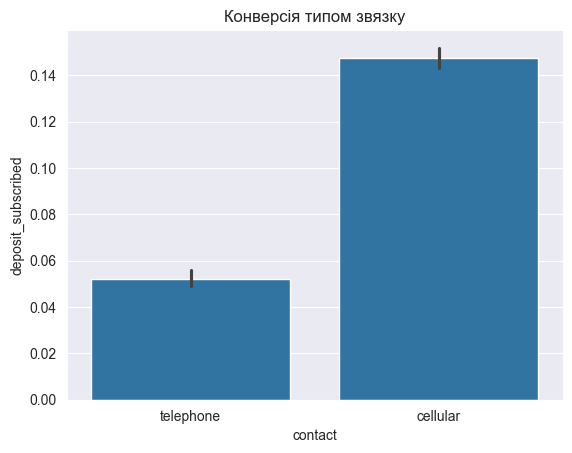

In [35]:
sns.barplot(
    data=raw_df,
    x="contact",
    y="deposit_subscribed"
)

plt.title("Конверсія типом звязку")
plt.show()

In [36]:
raw_df["contact"].value_counts()

contact
cellular     26144
telephone    15044
Name: count, dtype: int64

Тип звязку виявляє значний вплив на успішність дзвінка, в cellular конверсія значно вища. 

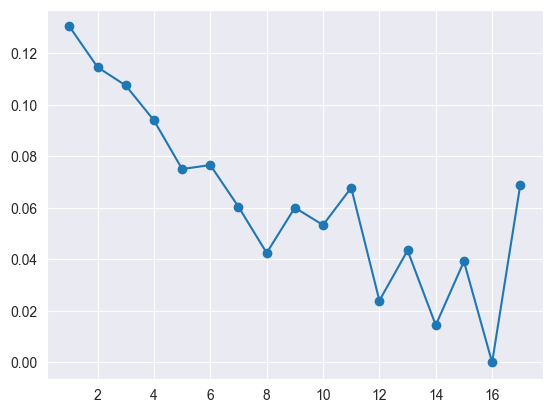

In [63]:
stats = raw_df.groupby("campaign")["deposit_subscribed"].agg(['mean', 'count'])

stats = stats[stats['count'] > 50]  # фільтр шуму

plt.plot(stats.index, stats['mean'], marker='o')

<Axes: xlabel='campaign', ylabel='y'>

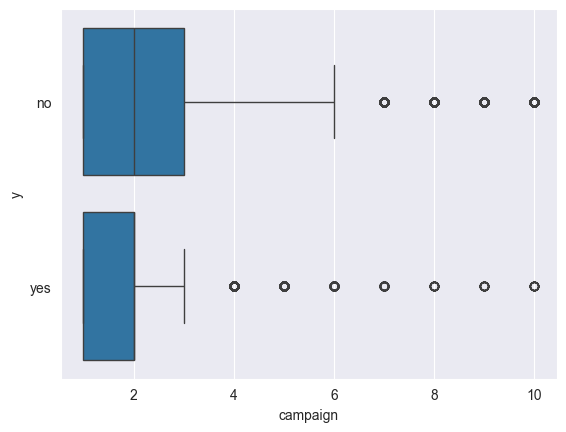

In [66]:
sns.boxplot(
    data=raw_df[raw_df["campaign"] <= 10],
    x="campaign",
    y="y"
)

Гіпотеза - чим більше контактів, тим менша конверсія.

Крок 2. Визначаємо методи та метрику оцінки.

Для такого типу задач доцільно буде використовувати методи бінарної класифікації, що здатні враховувати нелінійні залежності.
Як базову модель буду використовувати логістичну регресію, оскільки вона просто інтерпритується і дозволяє отримати базову оцінку якості. Для покращення якості варто застосувати ансамблеві методи, зокрема Random forest та Gradient boosting (XGBoost або LightGBM).
Для оцінки якості доцільно використати метрику ROC AUC, оскільки дані незбалансовані і використовувати accuracy немає сенсу. Додатково можна використати метрику F1 для більш детального аналізу. 

Крок 3. Препроцесинг даних для подальшої передачі в модель.

In [71]:
raw_df.columns[raw_df.isnull().any()]

Index([], dtype='object')

У датасеті немає колонок з пропущеними значеннями.

In [72]:
raw_df['job'].value_counts(normalize = True) * 100

job
admin.           25.303486
blue-collar      22.467709
technician       16.371273
services          9.636302
management        7.099155
retired           4.175974
entrepreneur      3.535010
self-employed     3.450034
housemaid         2.573565
unemployed        2.461882
student           2.124405
unknown           0.801204
Name: proportion, dtype: float64

In [73]:
raw_df['marital'].value_counts(normalize = True) * 100

marital
married     60.522482
single      28.085850
divorced    11.197436
unknown      0.194231
Name: proportion, dtype: float64

Понад 60% респондентів одружені, прирівняємо unknown до married.

In [74]:
raw_df['marital'] = raw_df['marital'].apply(lambda x: 'married' if x == 'unknown' else x)

In [76]:
raw_df['education'].value_counts(normalize = True) * 100

education
university.degree      29.542585
high.school            23.101389
basic.9y               14.676605
professional.course    12.729436
basic.4y               10.138875
basic.6y                5.564728
unknown                 4.202680
illiterate              0.043702
Name: proportion, dtype: float64

In [77]:
raw_df.groupby("education")["deposit_subscribed"].agg(['mean', 'count'])

,mean,count
education,,
basic.4y,0.102490,4176
basic.6y,0.082024,2292
basic.9y,0.078246,6045
high.school,0.108355,9515
illiterate,0.222222,18
professional.course,0.113485,5243
university.degree,0.137245,12168
unknown,0.145003,1731


In [78]:
raw_df['default'].value_counts(normalize = True) * 100

default
no         79.120132
unknown    20.872584
yes         0.007284
Name: proportion, dtype: float64

Понад 79% респондентів не мають простроченого кредиту, unknown - понад 20%. Є сенс розділити на 2 групи по ризиковості: yes/unknown = 1 (більший ризик), no = 0.

Препроцесинг даних у файлі process_marketing_calls.

In [191]:
X_train, y_train, X_val, y_val, input_cols, scaler, encoder, feature_names, artifacts = preprocess_data(
    raw_df,
    scaler_numeric=True,
    use_month=True,
    use_day_of_week=True,
)

Крок 4. Тренуємо моделі.

4.1. Логістична регресія

In [192]:
lr = LogisticRegression(
    max_iter=2000,
    C=0.02,
    solver="liblinear",
    class_weight="balanced",
    fit_intercept=True
)

lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.02
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :te

In [193]:
y_val_preds = lr.predict(X_val)
y_val_proba = lr.predict_proba(X_val)[:, 1]

print("Accuracy:", accuracy_score(y_val, y_val_preds))
print("ROC-AUC:", roc_auc_score(y_val, y_val_proba))

Accuracy: 0.8287205632435057
ROC-AUC: 0.8002960782348224


In [194]:
y_train_preds = lr.predict(X_train)
y_train_proba = lr.predict_proba(X_train)[:, 1]

print("Accuracy Train:", accuracy_score(y_train, y_train_preds))
print("ROC-AUC Train:", roc_auc_score(y_train, y_train_proba))

Accuracy Train: 0.8242488619119879
ROC-AUC Train: 0.7937279492500313


In [195]:
f1_score_ = f1_score(y_val, y_val_preds)
print(f"F1 score {lr}: {f1_score_:.2f}")

F1 score LogisticRegression(C=0.02, class_weight='balanced', max_iter=2000,
                   solver='liblinear'): 0.46


In [196]:
print(classification_report(y_val, y_val_preds))

              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7310
           1       0.36      0.65      0.46       928

    accuracy                           0.83      8238
   macro avg       0.65      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238



4.2. Тренуємо модель knn

In [139]:
knn = KNeighborsClassifier(n_neighbors=11)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [145]:
y_val_knn_preds = knn.predict(X_val)
y_val_knn_proba = knn.predict_proba(X_val)[:, 1]

print("Accuracy VAL KNN:", accuracy_score(y_val, y_val_knn_preds))
print("ROC-AUC VAL KNN:", roc_auc_score(y_val, y_val_knn_proba))

Accuracy VAL KNN: 0.898154891964069
ROC-AUC VAL KNN: 0.7628935179725459


In [146]:
f1_score_knn = f1_score(y_val, y_val_knn_preds)
print(f"F1 score {knn}: {f1_score_knn:.2f}")

F1 score KNeighborsClassifier(n_neighbors=11): 0.38


4.3. Тренуємо Decision Tree

In [144]:
d_tree = DecisionTreeClassifier(random_state=42)
d_tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [147]:
y_val_d_tree_preds = knn.predict(X_val)
y_val_d_tree_proba = knn.predict_proba(X_val)[:, 1]

print("Accuracy VAL Decision Tree:", accuracy_score(y_val, y_val_d_tree_preds))
print("ROC-AUC VAL Decision Tree:", roc_auc_score(y_val, y_val_d_tree_proba))

Accuracy VAL Decision Tree: 0.898154891964069
ROC-AUC VAL Decision Tree: 0.7628935179725459


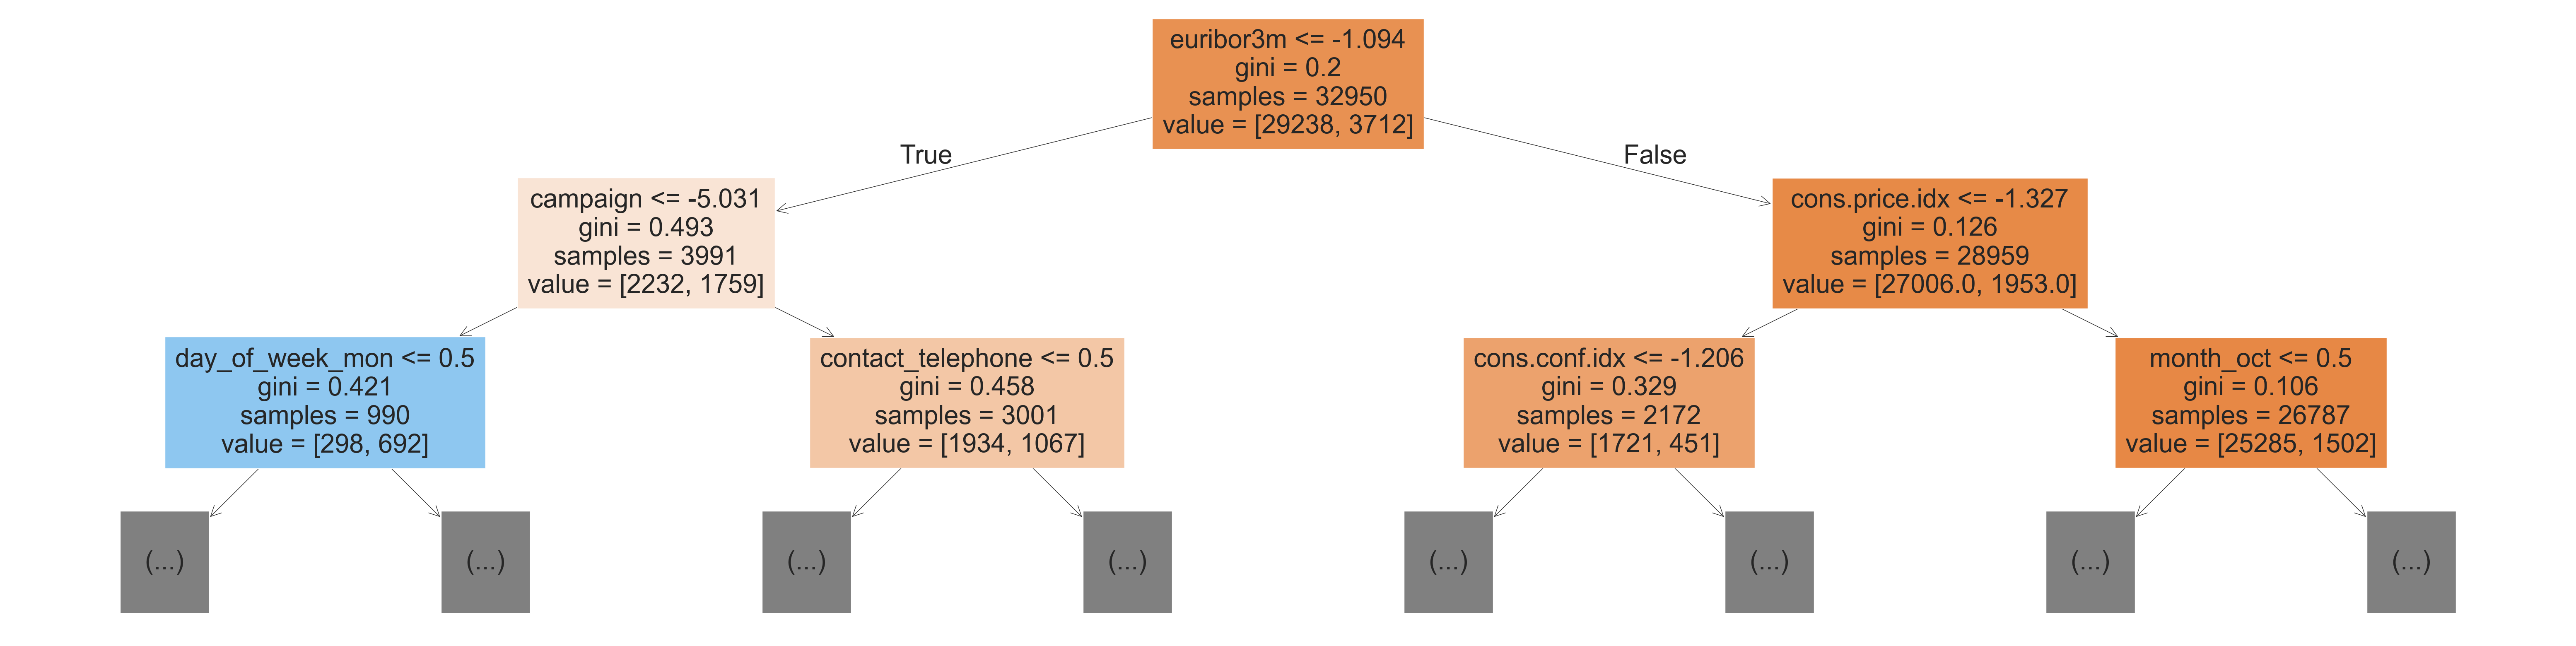

In [150]:
plt.figure(figsize=(80,20))
plot_tree(d_tree, feature_names=feature_names, max_depth=2, filled=True);

4.4. Натренуємо XGBoost та LightGBM

In [203]:
def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [204]:
df = pd.read_csv('bank-additional-full.csv', sep=';')

In [205]:
target_col = "y"
default_drop_cols = [target_col, "deposit_subscribed", "duration"]

df['y'] = df['y'].map(lambda x: 1 if x == 'yes' else 0)
input_cols = [
    c for c in df.columns
    if c not in default_drop_cols
]

In [206]:
train_df, val_df = split_train_val(df, target_col)
X_train, y_train = separate_inputs_targets(train_df, input_cols, target_col)
X_val, y_val = separate_inputs_targets(val_df, input_cols, target_col)

In [207]:
cat_cols = X_train.select_dtypes(include='object').columns

for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_val[col] = X_val[col].astype('category')

Тренуємо XGBoost

In [208]:
xgb_clf = XGBClassifier(
    max_depth=3,
    n_estimators=10,
    enable_categorical=True,  # для категорійних ознак
    missing=np.nan,  # явне вказування пропущених значень
    random_state=423
)

xgb_clf.fit(X_train, y_train)

train_pred = xgb_clf.predict(X_train)
val_pred = xgb_clf.predict(X_val)

print(classification_report(y_train, train_pred, digits=4))
print(classification_report(y_val, val_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9080    0.9892    0.9469     29238
           1     0.7125    0.2109    0.3255      3712

    accuracy                         0.9015     32950
   macro avg     0.8103    0.6001    0.6362     32950
weighted avg     0.8860    0.9015    0.8769     32950

              precision    recall  f1-score   support

           0     0.9072    0.9899    0.9467      7310
           1     0.7176    0.2026    0.3160       928

    accuracy                         0.9012      8238
   macro avg     0.8124    0.5962    0.6314      8238
weighted avg     0.8859    0.9012    0.8757      8238



In [209]:
train_probs = xgb_clf.predict_proba(X_train)[:,1]
val_probs = xgb_clf.predict_proba(X_val)[:,1]

print("ROC-AUC XGB Train:", roc_auc_score(y_train, train_probs))
print("ROC-AUC XGB Val:", roc_auc_score(y_val, val_probs))

ROC-AUC XGB Train: 0.8000532030087204
ROC-AUC XGB Val: 0.8067699979951886


Тренуємо LightGBM

In [220]:
cat_feature_indexes = [X_train.columns.get_loc(col) for col in cat_cols]

In [222]:
lgb_clf = lgb.LGBMClassifier(
    max_depth=3,
    n_estimators=50,
    learning_rate=0.1,
    cat_feature=cat_feature_indexes,  # для автоматичного розпізнавання категорійних ознак
    missing=np.nan,  # явне вказування пропущених значень
    verbose=-1
)

lgb_clf.fit(X_train, y_train, eval_set=[(X_val, y_val)])

train_pred = lgb_clf.predict(X_train)
val_pred = lgb_clf.predict(X_val)

print(classification_report(y_train, train_pred, digits=4))
print(classification_report(y_val, val_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9091    0.9884    0.9471     29238
           1     0.7091    0.2220    0.3381      3712

    accuracy                         0.9021     32950
   macro avg     0.8091    0.6052    0.6426     32950
weighted avg     0.8866    0.9021    0.8785     32950

              precision    recall  f1-score   support

           0     0.9082    0.9895    0.9471      7310
           1     0.7190    0.2123    0.3278       928

    accuracy                         0.9019      8238
   macro avg     0.8136    0.6009    0.6374      8238
weighted avg     0.8869    0.9019    0.8773      8238



In [212]:
lgb_val_probs = lgb_clf.predict_proba(X_val)[:,1]
lgb_train_probs = lgb_clf.predict_proba(X_train)[:,1]

lgb_train_roc_auc = roc_auc_score(y_train, lgb_train_probs)
lgb_val_roc_auc = roc_auc_score(y_val, lgb_val_probs)

[LightGBM] [Warning] Unknown parameter: missing
[LightGBM] [Warning] Unknown parameter: missing


In [213]:
print("ROC AUC lgb на тренувальній вибірці: {:.4f}".format(lgb_train_roc_auc))
print("ROC AUC lgb на валідаційній вибірці: {:.4f}".format(lgb_val_roc_auc))

ROC AUC lgb на тренувальній вибірці: 0.8064
ROC AUC lgb на валідаційній вибірці: 0.8110


Крок 5. Порівнюємо отримані моделі

In [214]:
def evaluate_model(model, X_train, y_train, X_val, y_val):
    model = clone(model)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    result = {
        "train_accuracy": accuracy_score(y_train, y_train_pred),
        "val_accuracy": accuracy_score(y_val, y_val_pred),
        "train_f1": f1_score(y_train, y_train_pred),
        "val_f1": f1_score(y_val, y_val_pred),
    }

    if hasattr(model, "predict_proba"):
        y_train_proba = model.predict_proba(X_train)[:, 1]
        y_val_proba = model.predict_proba(X_val)[:, 1]
        result["train_roc_auc"] = roc_auc_score(y_train, y_train_proba)
        result["val_roc_auc"] = roc_auc_score(y_val, y_val_proba)
    else:
        result["train_roc_auc"] = np.nan
        result["val_roc_auc"] = np.nan

    return result

In [215]:
X_train_enc, y_train, X_val_enc, y_val, input_cols, scaler, encoder, feature_names, artifacts = preprocess_data(
    df,
    scaler_numeric=True,
    use_month=True,
    use_day_of_week=True,
)

In [224]:
models = [
    {
        "name": "Logistic Regression",
        "model": lr,
        "X_train": X_train_enc,
        "X_val": X_val_enc,
        "comment": "Хороша стабільна модель baseline, показуєм найкращий F1 score на валідаційному наборі"
    },
    {
        "name": "KNN",
        "model": knn,
        "X_train": X_train_enc,
        "X_val": X_val_enc,
        "comment": "Працює гірше через високу розмірність після OHE."
    },
    {
        "name": "Decision Tree",
        "model": d_tree,
        "X_train": X_train_enc,
        "X_val": X_val_enc,
        "comment": "Може переобучатись, варто контролювати depth."
    },
    {
        "name": "XGBoost",
        "model": xgb_clf,
        "X_train": X_train,
        "X_val": X_val,
        "comment": "Хороша модель, ROC AUC ~80,068, але низький F1 score. Потрібно тюнити гіперпараметри."
    },
    {
        "name": "LightGBM",
        "model": lgb_clf,
        "X_train": X_train,
        "X_val": X_val,
        "comment": "Хороша модель, ROC AUC ~81,1, але низький F1 score (0.3381). Потрібно тюнити гіперпараметри, є потенціал."
    },
]

In [225]:
results = []

for item in models:
    metrics = evaluate_model(
        item["model"],
        item["X_train"], y_train,
        item["X_val"], y_val
    )

    results.append({
        "Model": item["name"],
        "Hyperparameters": str(item["model"]),
        "Train Accuracy": round(metrics["train_accuracy"], 4),
        "Val Accuracy": round(metrics["val_accuracy"], 4),
        "Train ROC-AUC": round(metrics["train_roc_auc"], 4) if pd.notna(metrics["train_roc_auc"]) else np.nan,
        "Val ROC-AUC": round(metrics["val_roc_auc"], 4) if pd.notna(metrics["val_roc_auc"]) else np.nan,
        "Train F1": round(metrics["train_f1"], 4),
        "Val F1": round(metrics["val_f1"], 4),
        "Comment": item["comment"],
    })

results_df = pd.DataFrame(results)
results_df["Hyperparameters"] = results_df["Hyperparameters"].str.replace("\n", " ", regex=False)
results_df

,Model,Hyperparameters,Train Accuracy,Val Accuracy,Train ROC-AUC,Val ROC-AUC,Train F1,Val F1,Comment
0,Logistic Regression,"LogisticRegression(C=0.02, class_weight='balanced', max_iter=2000, solver='liblinear')",0.8242,0.8290,0.7937,0.8003,0.4455,0.4628,"Хороша стабільна модель baseline, показуєм найкращий F1 score на валідаційному наборі"
1,KNN,KNeighborsClassifier(n_neighbors=11),0.9040,0.8980,0.8865,0.7624,0.4161,0.3778,Працює гірше через високу розмірність після OHE.
2,Decision Tree,DecisionTreeClassifier(random_state=42),0.9943,0.8336,0.9998,0.6210,0.9739,0.3169,"Може переобучатись, варто контролювати depth."
3,XGBoost,"XGBClassifier(base_score=None, booster=None, callbacks=None, colsample_bylevel=None, colsample_bynode=None, colsample_bytree=None, device=None, early_stopping_rounds=None, enable_categorical=True, eval_metric=None, feature_types=None, feature_weights=None, gamma=None, grow_policy=None, importance_type=None, interaction_constraints=None, learning_rate=None, max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=None, max_depth=3, max_leaves=None, min_child_weight=None, missing=nan, monotone_constraints=None, multi_strategy=None, n_estimators=10, n_jobs=None, num_parallel_tree=None, ...)",0.9015,0.9012,0.8001,0.8068,0.3255,0.3160,"Хороша модель, ROC AUC ~80,068, але низький F1 score. Потрібно тюнити гіперпараметри."
4,LightGBM,"LGBMClassifier(cat_feature=[1, 2, 3, 4, 5, 6, 7, 8, 9, 13], max_depth=3, missing=nan, n_estimators=50, verbose=-1)",0.9021,0.9019,0.8064,0.8110,0.3381,0.3278,"Хороша модель, ROC AUC ~81,1, але низький F1 score (0.3381). Потрібно тюнити гіперпараметри, є потенціал."


Крок 6. Тюнимо гіперпараметри для LightGBM

6.1. Hyperopt: Bayesian Optimization

In [237]:
def objective(params):
    clf = lgb.LGBMClassifier(
        n_estimators=int(params['n_estimators']),  # Кількість дерев у ансамблі (кількість ітерацій бустингу)
        learning_rate=params['learning_rate'],  # Коефіцієнт, на який зменшується внесок кожного доданого дерева
        max_depth=int(params['max_depth']),  # Максимальна глибина кожного дерева
        num_leaves=int(params['num_leaves']),  # Максимальна кількість листків, що дозволяємо кожному дереву мати.
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        min_split_gain=params['min_split_gain'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        cat_feature=cat_feature_indexes,  # Індекси категорійних ознак
        verbose=-1
    )
    
    clf.fit(X_train, y_train, eval_set=[(X_val, y_val)])
    val_probs = clf.predict_proba(X_val)[:,1]
    roc_auc = roc_auc_score(y_val, val_probs)

    return {'loss': -roc_auc, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
    'max_depth': hp.quniform('max_depth', 3, 20, 1),
    'num_leaves': hp.quniform('num_leaves', 20, 50, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1),
    'min_split_gain': hp.uniform('min_split_gain', 0, 0.1)  # додано мінімальне зменшення втрат для поділу
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials, rstate=default_rng(42))

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['num_leaves'] = int(best['num_leaves'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_clf = lgb.LGBMClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    num_leaves=best['num_leaves'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    min_split_gain=best['min_split_gain'],
    cat_feature=cat_feature_indexes,
    missing=np.nan,
    verbose=-1
)

final_clf.fit(X_train, y_train, eval_set=[(X_val, y_val)])
final_lgb_pred = final_clf.predict(X_val)
final_lgb_train_probs = final_clf.predict_proba(X_train)[:,1]
final_lgb_val_probs = final_clf.predict_proba(X_val)[:,1]
final_lgb_roc_auc_train = roc_auc_score(y_train, final_lgb_train_probs)
final_lgb_roc_auc = roc_auc_score(y_val, final_lgb_val_probs)

print("ROC AUC Final LGB на тренувальній вибірці: {:.4f}".format(final_lgb_roc_auc_train))
print("ROC AUC Final LGB на валідаційній вибірці: {:.4f}".format(final_lgb_roc_auc))

print(classification_report(y_val, final_lgb_pred, digits=4))

100%|██████████| 10/10 [00:13<00:00,  1.32s/trial, best loss: -0.816882282183122]
Найкращі гіперпараметри:  {'colsample_bytree': np.float64(0.5911413880562895), 'learning_rate': np.float64(0.05796037104407459), 'max_depth': 13, 'min_child_weight': 3, 'min_split_gain': np.float64(0.05007506098950729), 'n_estimators': 75, 'num_leaves': 41, 'reg_alpha': np.float64(0.5924534133258075), 'reg_lambda': np.float64(0.21221711699333523), 'subsample': np.float64(0.7018888351309895)}
ROC AUC Final LGB на тренувальній вибірці: 0.8421
ROC AUC Final LGB на валідаційній вибірці: 0.8169
              precision    recall  f1-score   support

           0     0.9146    0.9834    0.9478      7310
           1     0.6799    0.2769    0.3936       928

    accuracy                         0.9039      8238
   macro avg     0.7973    0.6302    0.6707      8238
weighted avg     0.8882    0.9039    0.8854      8238



Модель хороша, немає ознак оверфіту, різниця ROC AUC між тренувальними і валідаційними даними, різниця ~0.03. Покращився F1 score. Модель добре прогнозує 0 клас, але все ще дуже обережна з 1.

6.2. Sklearn: Randomized Search

In [247]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API"
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

lgb_base = lgb.LGBMClassifier(
    objective="binary",
    random_state=42,
    verbose=-1,
    cat_feature=cat_feature_indexes,
    scale_pos_weight=scale_pos_weight,
)

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": np.linspace(0.01, 0.2, 20),
    "max_depth": [3, 4, 5, 6, 8, 10, -1],
    "num_leaves": [15, 31, 50, 70, 100, 150],
    "min_child_weight": [1, 3, 5, 7, 10],
    "subsample": np.linspace(0.6, 1.0, 10),
    "colsample_bytree": np.linspace(0.6, 1.0, 10),
    "reg_alpha": np.linspace(0.0, 1.0, 20),
    "reg_lambda": np.linspace(0.0, 1.0, 20),
    "min_split_gain": np.linspace(0.0, 0.1, 20),
}

random_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    verbose=False,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_lgb_random = random_search.best_estimator_
print("Best params (RandomizedSearchCV):")
print(random_search.best_params_)
print("Best CV ROC-AUC:", random_search.best_score_)

/Users/oleh/miniconda3/envs/ml_dev/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/oleh/miniconda3/envs/ml_dev/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/oleh/miniconda3/envs/ml_dev/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from usi

Best params (RandomizedSearchCV):
{'subsample': np.float64(0.9555555555555555), 'reg_lambda': np.float64(0.21052631578947367), 'reg_alpha': np.float64(0.47368421052631576), 'num_leaves': 31, 'n_estimators': 300, 'min_split_gain': np.float64(0.1), 'min_child_weight': 10, 'max_depth': -1, 'learning_rate': np.float64(0.01), 'colsample_bytree': np.float64(0.6)}
Best CV ROC-AUC: 0.7989630398149199


In [245]:
final_rs_pred = best_lgb_random.predict(X_val)
final_rs_train_probs = best_lgb_random.predict_proba(X_train)[:,1]
final_rs_val_probs = best_lgb_random.predict_proba(X_val)[:,1]
final_rs_roc_auc_train = roc_auc_score(y_train, final_rs_train_probs)
final_rs_roc_auc = roc_auc_score(y_val, final_rs_val_probs)

In [246]:
print("ROC AUC Final LGB RandomSearch на тренувальній вибірці: {:.4f}".format(final_rs_roc_auc_train))
print("ROC AUC Final LGB RandomSearch на валідаційній вибірці: {:.4f}".format(final_rs_roc_auc))

print(classification_report(y_val, final_rs_pred, digits=4))

ROC AUC Final LGB RandomSearch на тренувальній вибірці: 0.8433
ROC AUC Final LGB RandomSearch на валідаційній вибірці: 0.8179
              precision    recall  f1-score   support

           0     0.9521    0.8865    0.9181      7310
           1     0.4204    0.6487    0.5102       928

    accuracy                         0.8597      8238
   macro avg     0.6862    0.7676    0.7141      8238
weighted avg     0.8922    0.8597    0.8722      8238



Модель виявилась кращою за Bayesian Optimization. Не оверфіт, найкращий ROC AUC 0.8179. Модель менш обережна і краще виявляє позитивний клас, F1 score покращився до 0.51.

Крок 7. Виводимо важливість ознак для моделі, яка показала себе найкраще (Randomized Search)

In [250]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_lgb_random.feature_importances_
})

feature_importance = feature_importance.sort_values(by="importance", ascending=False)

feature_importance.head(15)

,feature,importance
17,euribor3m,1676
0,age,1190
10,campaign,846
1,job,764
15,cons.price.idx,457
9,day_of_week,455
3,education,432
8,month,400
16,cons.conf.idx,383
7,contact,323


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

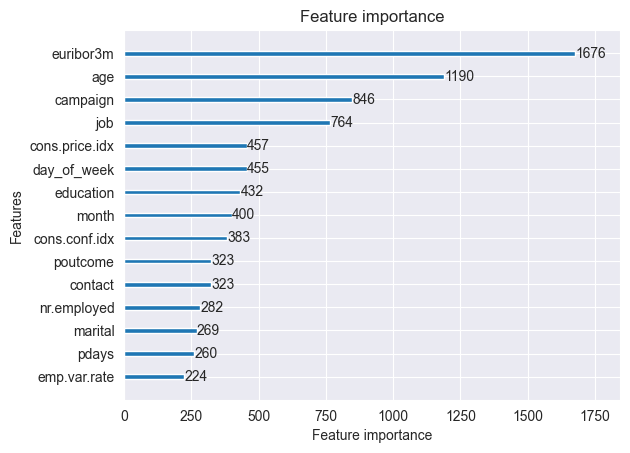

In [251]:
lgb.plot_importance(best_lgb_random, max_num_features=15)

Результат розподілу важливості ознак виглядає досить логічним. Короткий аналіз основних ознак з найбільшим впливом:


In [ ]:
# Найважливішою ознакою виявилась ставка euribor3m - яка вже сама по собі дає уявлення про стан економіки, наявність чи відсутність кризи. Високі ставки - попит на пасиви у банку високий, важко залучити клієнта.
# Вік - тут закономірно, старші люди частіше роблять заощадження.
# Campaign - кількість контактів у межах компанії, зазвичай клієнт погоджується за 1-2 контакти, якщо більше - може "перегоріти".
# job - представники певних професій мають вищий і стабільніший дохід який можуть відкласти для накопичень
# cons.price.idx, cons.conf.idx - економічні показники, які характеризують споживчі настрої та довіру в певний період часу
# month, day_of_week - тут швидше результат попередніх компаній, які проходили в певні місяці, можуть вводити в оману
# education - рівень освіти впливає на дохід клієнта, що в свою чергу дає можливість накопичувати кошти на вкладі
# poutcome - результат попередньої маркетингової компанії - лояльні клієнти більш схильні до повторних розміщень коштів 

In [252]:
import shap

# створюємо обʼєкт для пояснення прогнозів моделі за допомогою SHAP
explainer = shap.TreeExplainer(best_lgb_random)
shap_values = explainer.shap_values(X_train)

# візуалізуємо пояснення першого прогнозу
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X_train.iloc[0,:])

/Users/oleh/miniconda3/envs/ml_dev/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning:

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray



- Ознаки, які підвищують прогноз (синім кольором):
- euribor3m, nr.employed, age, default, cons.conf.idx, pdays
- Знижують прогноз (червоним кольором):
- contact, cons.price.idx, emp.var.rate, day_of_week
- Значення виходу становить -1.10 при euribor3m = 4.12, nr.employed = 5.196, age=49, default=unknown, cons.conf.idx=-42, pdays=999, contact=cellular, cons.price.idx=93.2, emp.var.rate=-0.1, day_of_week=wed


In [253]:
X_train.euribor3m.describe()

count    32950.000000
mean         3.618395
std          1.735896
min          0.634000
25%          1.344000
50%          4.857000
75%          4.961000
max          5.045000
Name: euribor3m, dtype: float64

In [254]:
X_train.iloc[0,:]

age                        49
job               blue-collar
marital               married
education            basic.9y
default               unknown
housing                    no
loan                       no
contact              cellular
month                     nov
day_of_week               wed
campaign                    4
pdays                     999
previous                    0
poutcome          nonexistent
emp.var.rate             -0.1
cons.price.idx           93.2
cons.conf.idx           -42.0
euribor3m                4.12
nr.employed            5195.8
Name: 25611, dtype: object

In [255]:
# Вибираємо випадкові 500 рядків (або іншу розумну кількість)
sample_size = 500
subset_indices = np.random.choice(X_train.shape[0], sample_size, replace=False)

# Створюємо підмножину SHAP значень
shap_values_subset = shap_values[subset_indices]
X_train_subset = X_train.iloc[subset_indices]

# Візуалізація для підмножини
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values_subset, X_train_subset)

/Users/oleh/miniconda3/envs/ml_dev/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning:

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray



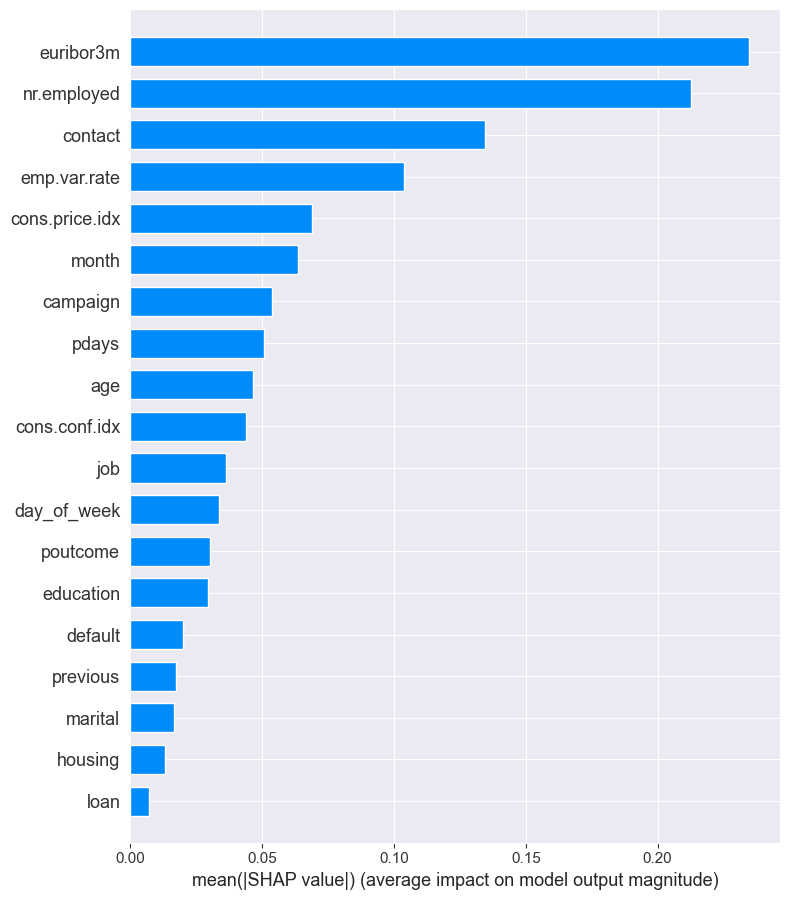

In [256]:
shap_values = shap.TreeExplainer(best_lgb_random).shap_values(X_train)  # Обчислення значень SHAP
shap.summary_plot(shap_values, X_train, plot_type="bar")  # Побудова підсумкового графіка SHAP

Спостерігаємо дещо інший ренж впливу ознак в порівнянні із вбудованим методом моделі feature_importance_. В обох випадках найважливішою ознакою виявилась ставка euribor3m, проте далі порядок інший, тут більш важливими виявились nr.employed, contact, emp.var.rate.

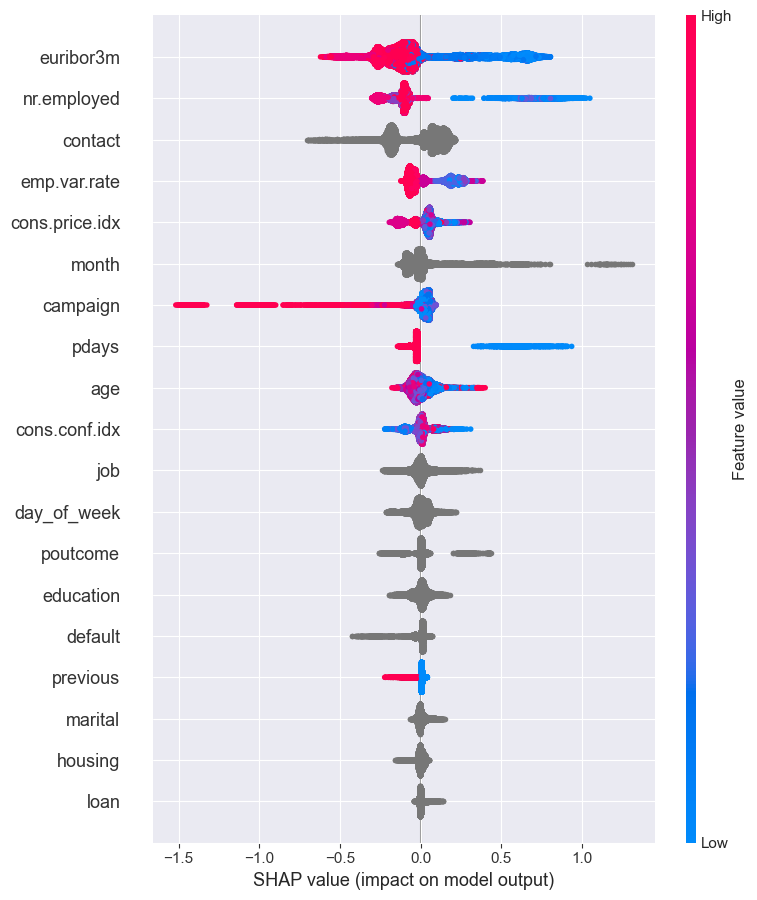

In [257]:
# Візуалізація підсумкових значень SHAP для навчального набору даних
shap.summary_plot(shap_values, X_train)

Низький рівень euribor3m має позитивний вплив на ймовірність підписання депозитної угоди (відповідає економічній логіці). Ознака compaign - демонструє що що збільшення кількості контактів з клієнтом має негативний вплив на результат. Poutcome - має сильний позитивний вплив - попередній позитивний досвід клієнта підвищує ймовірність успіху в поточній компанії.